# Assignment 7 : SVM Regressor

### A quick note on SVR:
Support Vector Regression extends the same margin-based idea from SVM classification to continuous targets. Instead of maximizing the margin between classes, SVR fits a function within an **ε-insensitive tube** around the data — predictions within ε of the true value incur zero loss, and only points *outside* the tube contribute to the loss, weighted by C:$$f(x) = \sum_i (\alpha_i - \alpha_i^*)\, K(x_i, x) + b$$where $K$ is the kernel (linear: $K(x,x')=x \cdot x'$; RBF: $K(x,x')=\exp(-\gamma\|x-x'\|^2)$). $C$ controls the trade-off between a flatter/simpler function and tolerating fewer points outside the tube (larger $C$ → less tolerance, tighter fit to training data); $\varepsilon$ controls how wide that zero-loss tube is (larger $\varepsilon$ → more tolerance for small errors, but potentially more bias). $\gamma$ (RBF only) controls how far each training point's influence reaches, same role as in SVC.

### A Quick Look at the Kernel Trick
Many algorithms, including SVMs, only ever need to compute **dot products** between data points — never the points themselves. The kernel trick exploits this: instead of explicitly transforming data into a higher-dimensional space where it becomes linearly separable, we compute a kernel function $K(x, x')$ that equals the dot product of the transformed points, *without ever computing the transformation itself*.**A concrete toy example.** Take 2D points $x = (x_1, x_2)$, and define the mapping $\varphi(x) = (x_1^2,\ \sqrt{2}\,x_1 x_2,\ x_2^2)$, lifting each point into 3D. It turns out that:$$\varphi(x) \cdot \varphi(x') = (x_1 x_1' + x_2 x_2')^2 = (x \cdot x')^2$$So instead of explicitly computing $\varphi(x)$ and $\varphi(x')$ (3 numbers each) and then their dot product, we can just compute $(x \cdot x')^2$ directly on the original 2D points — this *is* the polynomial kernel of degree 2. Same result, far less computation, and the trick scales to spaces with far more dimensions (even infinite, as with the RBF kernel) where explicitly computing $\varphi(x)$ wouldn't be feasible at all.

## Task-0:
Pick any two 2D points $x = (x_1, x_2)$ and $x' = (x_1', x_2')$. Write code to:(a) Compute $\varphi(x)$ and $\varphi(x')$ explicitly using the mapping above, then take their dot product.(b) Compute $(x \cdot x')^2$ directly on the original points.Confirm both give the same result.

In [1]:
import numpy as np

# two arbitrary 2D points
x = np.array([2.0, 3.0])
x_prime = np.array([4.0, 5.0])

# explicit feature mapping phi(x) = (x1^2, sqrt(2)*x1*x2, x2^2) into 3D
def phi(pt):
    return np.array([pt[0]**2, np.sqrt(2) * pt[0] * pt[1], pt[1]**2])

# Explicit mapping into 3D and dot product
phi_x = phi(x)
phi_x_prime = phi(x_prime)
dot_product_phi = np.dot(phi_x, phi_x_prime)

# Direct computation using polynomial kernel (x . x')^2 in original 2D space
dot_product_kernel = np.dot(x, x_prime) ** 2

# Output results and confirmation
print(f"Point x: {x}")
print(f"Point x': {x_prime}")
print("-" * 50)
print(f"Transformed phi(x):      {phi_x}")
print(f"Transformed phi(x'):     {phi_x_prime}")
print(f"(a) Explicit dot product <phi(x), phi(x')>: {dot_product_phi:.6f}")
print(f"(b) Kernel trick (x . x')^2:                {dot_product_kernel:.6f}")
print("-" * 50)
print(f"Both values equal? -> {np.isclose(dot_product_phi, dot_product_kernel)}")


Point x: [2. 3.]
Point x': [4. 5.]
--------------------------------------------------
Transformed phi(x):      [4.         8.48528137 9.        ]
Transformed phi(x'):     [16.         28.28427125 25.        ]
(a) Explicit dot product <phi(x), phi(x')>: 529.000000
(b) Kernel trick (x . x')^2:                529.000000
--------------------------------------------------
Both values equal? -> True


## Task-1:
1. Load the [Energy Efficiency dataset](https://archive.ics.uci.edu/dataset/242/energy+efficiency) from UCI. Use `Y1` (Heating Load) as the regression target.
2. Split the dataset into training, validation and test sets (70%-15%-15%).

In [2]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVR
from sklearn.metrics import mean_squared_error, r2_score

from ucimlrepo import fetch_ucirepo

import urllib.request
import io
import zipfile

import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
# Load Energy Efficiency dataset from UCI
try:
    energy_efficiency = fetch_ucirepo(id=242)
    X = energy_efficiency.data.features
    y = energy_efficiency.data.targets['Y1']  # Y1: Heating Load
except Exception:
    # Fallback to direct download if ucimlrepo is unavailable
    url = "https://archive.ics.uci.edu/static/public/242/energy+efficiency.zip"
    req = urllib.request.urlopen(url)
    z = zipfile.ZipFile(io.BytesIO(req.read()))
    df = pd.read_excel(z.open('ENB2012_data.xlsx'))
    X = df[['X1', 'X2', 'X3', 'X4', 'X5', 'X6', 'X7', 'X8']]
    y = df['Y1']

print("Features Shape:", X.shape)
print("Target Shape:", y.shape)
print("\nFirst 5 observations:")
X.head()

Features Shape: (768, 8)
Target Shape: (768,)

First 5 observations:


,X1,X2,X3,X4,X5,X6,X7,X8
0,0.98,514.5,294.0,110.25,7.0,2,0.0,0
1,0.98,514.5,294.0,110.25,7.0,3,0.0,0
2,0.98,514.5,294.0,110.25,7.0,4,0.0,0
3,0.98,514.5,294.0,110.25,7.0,5,0.0,0
4,0.90,563.5,318.5,122.50,7.0,2,0.0,0


In [4]:
# Split dataset into Train (70%), Validation (15%), and Test (15%)
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, random_state=42
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=42
)

# Display split summary table
split_summary = pd.DataFrame({
    'Subset': ['Training', 'Validation', 'Testing', 'Total'],
    'Samples': [len(X_train), len(X_val), len(X_test), len(X)],
    'Percentage (%)': [
        len(X_train)/len(X)*100,
        len(X_val)/len(X)*100,
        len(X_test)/len(X)*100,
        100.0
    ]
})
print("\nDataset Split Summary:")
split_summary


Dataset Split Summary:


,Subset,Samples,Percentage (%)
0,Training,537,69.921875
1,Validation,115,14.973958
2,Testing,116,15.104167
3,Total,768,100.000000


## Task-2:
1. Perform feature scaling such that the features lie in the same range of values.
2. Show the correlation between the features of the training set.

In [5]:
# Perform feature scaling using StandardScaler
scaler = StandardScaler()
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train), columns=X_train.columns, index=X_train.index)
X_val_scaled = pd.DataFrame(scaler.transform(X_val), columns=X_val.columns, index=X_val.index)
X_test_scaled = pd.DataFrame(scaler.transform(X_test), columns=X_test.columns, index=X_test.index)

print("Scaled Training Features Summary (StandardScaler):")
X_train_scaled.describe().round(3)

Scaled Training Features Summary (StandardScaler):


,X1,X2,X3,X4,X5,X6,X7,X8
count,537.000,537.000,537.000,537.000,537.000,537.000,537.000,537.000
mean,0.000,0.000,-0.000,-0.000,-0.000,0.000,0.000,-0.000
std,1.001,1.001,1.001,1.001,1.001,1.001,1.001,1.001
min,-1.341,-1.829,-1.690,-1.515,-0.972,-1.358,-1.761,-1.850
25%,-0.959,-0.711,-0.565,-0.695,-0.972,-0.453,-1.015,-0.554
50%,-0.194,0.127,-0.003,0.946,-0.972,-0.453,0.105,0.094
75%,0.570,0.965,0.559,0.946,1.028,0.451,1.224,0.742
max,2.098,1.524,2.246,0.946,1.028,1.356,1.224,1.390


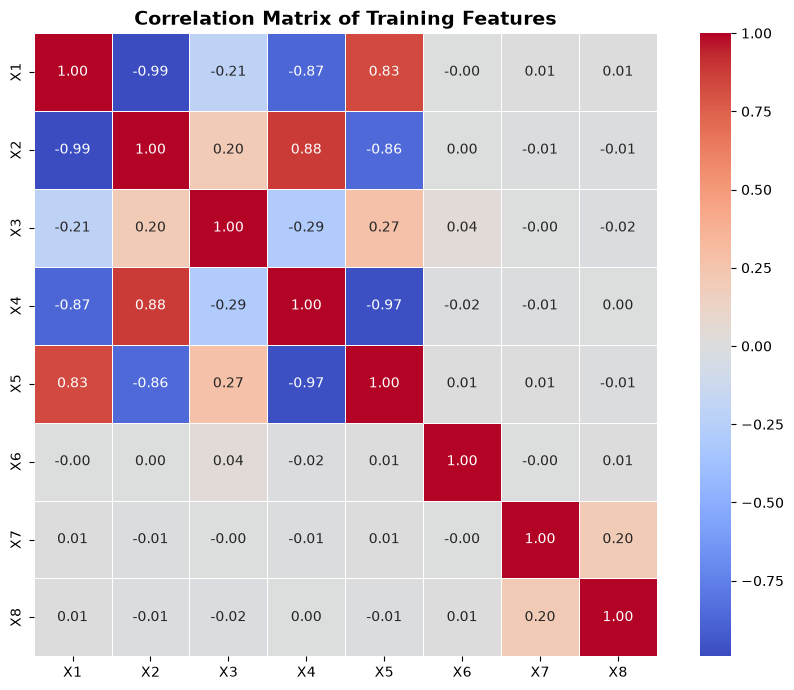

In [6]:
# Plot correlation
plt.figure(figsize=(9, 7))
corr_matrix = X_train_scaled.corr()
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", cbar=True, square=True, linewidths=0.5)
plt.title("Correlation Matrix of Training Features", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## Task-3:
1. Fit an SVM with linear kernel on the training set using sklearn's SVR. 
2. Tune the hyperparameters C and ε on the validation set using grid search (Take range of values of C and ε as provided below).

C = 0.01, 0.1, 1, 10, 100; ε = 0.001, 0.01, 0.1, 0.5, 1.0

In [7]:
# Fit an initial linear SVM regressor on training set
svm_linear_init = SVR(kernel='linear')
svm_linear_init.fit(X_train_scaled, y_train)

y_val_init_pred = svm_linear_init.predict(X_val_scaled)
print(f"Initial Linear SVR (default params) - Val MSE: {mean_squared_error(y_val, y_val_init_pred):.4f}, Val R^2: {r2_score(y_val, y_val_init_pred):.4f}\n")


Initial Linear SVR (default params) - Val MSE: 10.9741, Val R^2: 0.8926



In [8]:
# Hyperparameter grid search for C and epsilon on validation set
C_values_lin = [0.01, 0.1, 1, 10, 100]
epsilon_values_lin = [0.001, 0.01, 0.1, 0.5, 1.0]

linear_grid_results = []
best_linear_val_mse = float('inf')
best_linear_params = None

for C in C_values_lin:
    for eps in epsilon_values_lin:
        model = SVR(kernel='linear', C=C, epsilon=eps)
        model.fit(X_train_scaled, y_train)
        pred_val = model.predict(X_val_scaled)
        mse_val = mean_squared_error(y_val, pred_val)
        r2_val = r2_score(y_val, pred_val)
        
        linear_grid_results.append({
            'C': C,
            'epsilon': eps,
            'Val_MSE': mse_val,
            'Val_R2': r2_val
        })
        
        if mse_val < best_linear_val_mse:
            best_linear_val_mse = mse_val
            best_linear_params = {'C': C, 'epsilon': eps}

In [9]:
# grid search results
df_linear_grid = pd.DataFrame(linear_grid_results)
print("--- Grid Search Results (Linear SVR Validation MSE) ---")
df_linear_grid.pivot(index='C', columns='epsilon', values='Val_MSE').round(4)

--- Grid Search Results (Linear SVR Validation MSE) ---


epsilon,0.001,0.010,0.100,0.500,1.000
C,,,,,
0.01,23.6197,23.6622,23.6256,23.2925,23.9462
0.10,13.7015,13.7120,13.5463,13.2863,13.1944
1.00,11.0706,11.0629,10.9741,10.8115,10.6842
10.00,10.7367,10.7471,10.8337,10.5842,10.3745
100.00,10.7824,10.8137,10.8054,10.6259,10.3700


In [10]:
print("\n" + "="*50)
print(f"Best Linear SVR Hyperparameters: C = {best_linear_params['C']}, epsilon = {best_linear_params['epsilon']}")
print(f"Best Validation MSE: {best_linear_val_mse:.4f}")
print("="*50)


Best Linear SVR Hyperparameters: C = 100, epsilon = 1.0
Best Validation MSE: 10.3700


## Task-4:
1. Evaluate the linear SVM regressor using the best value of C and ε you obtained. Report the performance in terms of MSE and R^2 score. 
2. Show a scatter plot of the predictions of the linear SVR model vs. the ground truth target values.

In [11]:
# Evaluate the best Linear SVM Regressor on the test set
best_linear_svr = SVR(kernel='linear', C=best_linear_params['C'], epsilon=best_linear_params['epsilon'])
best_linear_svr.fit(X_train_scaled, y_train)

,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm.If none is given, 'rbf' will be used. If a callable is given it isused to precompute the kernel matrix.For an intuitive visualization of different kernel typessee :ref:`sphx_glr_auto_examples_svm_plot_svm_regression.py`",'linear'
,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive.The penalty is a squared l2. For an intuitive visualization of theeffects of scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",100
,"epsilon epsilon: float, default=0.1Epsilon in the epsilon-SVR model. It specifies the epsilon-tubewithin which no penalty is associated in the training loss functionwith points predicted within a distance epsilon from the actualvalue. Must be non-negative.",1.0
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide <shrinking_svm>`.",True
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False
,"max_iter max_iter: int, default=-1Hard limit on iterations within solver, or -1 for no limit.",-1


In [12]:
# Predictions on train, val, and test sets
y_train_pred_lin = best_linear_svr.predict(X_train_scaled)
y_val_pred_lin = best_linear_svr.predict(X_val_scaled)
y_test_pred_lin = best_linear_svr.predict(X_test_scaled)

train_mse_lin = mean_squared_error(y_train, y_train_pred_lin)
train_r2_lin = r2_score(y_train, y_train_pred_lin)

val_mse_lin = mean_squared_error(y_val, y_val_pred_lin)
val_r2_lin = r2_score(y_val, y_val_pred_lin)

test_mse_lin = mean_squared_error(y_test, y_test_pred_lin)
test_r2_lin = r2_score(y_test, y_test_pred_lin)

In [13]:
# Evaluation report table
perf_linear_df = pd.DataFrame({
    'Metric': ['MSE', 'R^2 Score'],
    'Training Set': [train_mse_lin, train_r2_lin],
    'Validation Set': [val_mse_lin, val_r2_lin],
    'Test Set': [test_mse_lin, test_r2_lin]
})
print("Linear SVR Model Performance Report:")
perf_linear_df.round(4)

Linear SVR Model Performance Report:


,Metric,Training Set,Validation Set,Test Set
0,MSE,8.6738,10.3700,7.8180
1,R^2 Score,0.9146,0.8985,0.9202


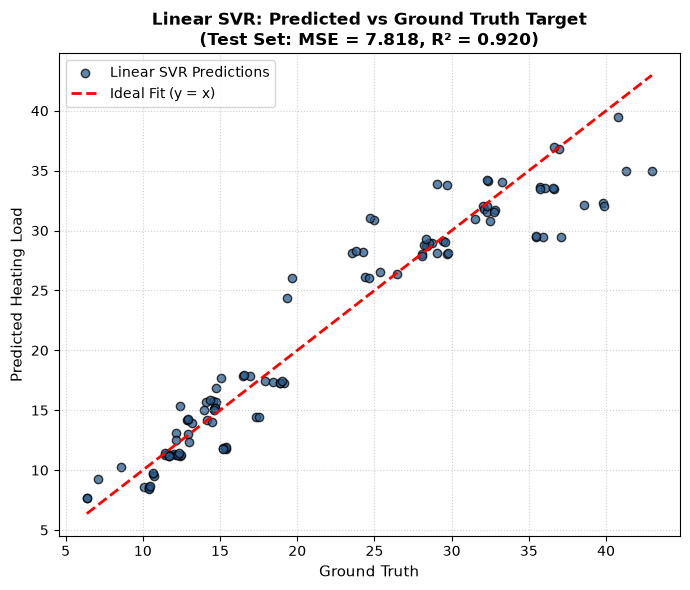

In [14]:
# Scatter plot
plt.figure(figsize=(7, 6))
plt.scatter(y_test, y_test_pred_lin, color='#2b5c8f', alpha=0.75, edgecolors='k', label='Linear SVR Predictions')

# Ideal 45-degree line (y = x)
min_val = min(y_test.min(), y_test_pred_lin.min())
max_val = max(y_test.max(), y_test_pred_lin.max())
plt.plot([min_val, max_val], [min_val, max_val], 'r--', lw=2, label='Ideal Fit (y = x)')

plt.title(f"Linear SVR: Predicted vs Ground Truth Target\n(Test Set: MSE = {test_mse_lin:.3f}, R² = {test_r2_lin:.3f})", fontsize=12, fontweight='bold')
plt.xlabel("Ground Truth", fontsize=11)
plt.ylabel("Predicted Heating Load", fontsize=11)
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend(frameon=True)
plt.tight_layout()
plt.show()

## Task-5:
1. Fit an SVM with RBF kernel on the training set using sklearn's SVR. 
2. Tune the hyperparameters C, γ and ε on the validation set using grid search (Take range of values of C, γ and ε as provided below).

C = 0.1, 1, 10, 100, 1000; γ = 0.001, 0.01, 0.1, 1, 10; ε = 0.01, 0.1, 0.5, 1.0

In [15]:
# Fit an initial SVM with RBF kernel on training set
svm_rbf_init = SVR(kernel='rbf')
svm_rbf_init.fit(X_train_scaled, y_train)

y_val_rbf_init_pred = svm_rbf_init.predict(X_val_scaled)
print(f"Initial RBF SVR (default params) - Val MSE: {mean_squared_error(y_val, y_val_rbf_init_pred):.4f}, Val R^2: {r2_score(y_val, y_val_rbf_init_pred):.4f}\n")


Initial RBF SVR (default params) - Val MSE: 9.0789, Val R^2: 0.9112



In [16]:
# Hyperparameter grid search for C, gamma, and epsilon on validation set
C_values_rbf = [0.1, 1, 10, 100, 1000]
gamma_values_rbf = [0.001, 0.01, 0.1, 1, 10]
epsilon_values_rbf = [0.01, 0.1, 0.5, 1.0]

rbf_grid_results = []
best_rbf_val_mse = float('inf')
best_rbf_params = None

for C in C_values_rbf:
    for gamma in gamma_values_rbf:
        for eps in epsilon_values_rbf:
            model = SVR(kernel='rbf', C=C, gamma=gamma, epsilon=eps)
            model.fit(X_train_scaled, y_train)
            pred_val = model.predict(X_val_scaled)
            mse_val = mean_squared_error(y_val, pred_val)
            r2_val = r2_score(y_val, pred_val)
            
            rbf_grid_results.append({
                'C': C,
                'gamma': gamma,
                'epsilon': eps,
                'Val_MSE': mse_val,
                'Val_R2': r2_val
            })
            
            if mse_val < best_rbf_val_mse:
                best_rbf_val_mse = mse_val
                best_rbf_params = {'C': C, 'gamma': gamma, 'epsilon': eps}

In [17]:
df_rbf_grid = pd.DataFrame(rbf_grid_results)
print("Top 10 Hyperparameter Configurations (RBF SVR) by Validation MSE:")
df_rbf_grid.sort_values(by='Val_MSE').head(10).round(4)

Top 10 Hyperparameter Configurations (RBF SVR) by Validation MSE:


,C,gamma,epsilon,Val_MSE,Val_R2
89,1000.0,0.1,0.10,0.2875,0.9972
88,1000.0,0.1,0.01,0.3028,0.9970
90,1000.0,0.1,0.50,0.4595,0.9955
91,1000.0,0.1,1.00,0.9944,0.9903
71,100.0,0.1,1.00,2.2687,0.9778
70,100.0,0.1,0.50,2.4621,0.9759
69,100.0,0.1,0.10,2.6677,0.9739
68,100.0,0.1,0.01,2.7259,0.9733
92,1000.0,1.0,0.01,3.1323,0.9694
72,100.0,1.0,0.01,3.1323,0.9694


In [18]:
print("\n" + "="*60)
print(f"Best RBF SVR Hyperparameters: C = {best_rbf_params['C']}, gamma = {best_rbf_params['gamma']}, epsilon = {best_rbf_params['epsilon']}")
print(f"Best Validation MSE: {best_rbf_val_mse:.4f}")
print("="*60)


Best RBF SVR Hyperparameters: C = 1000, gamma = 0.1, epsilon = 0.1
Best Validation MSE: 0.2875


## Task-6:
1. Evaluate the RBF SVM regressor using the best value of C, γ and ε you obtained. Report the performance in terms of MSE and R^2 score.
2. Show a scatter plot of the predictions of the RBF SVR model vs. the ground truth target values.

In [19]:
# Evaluate the best RBF SVM Regressor on test set
best_rbf_svr = SVR(kernel='rbf', C=best_rbf_params['C'], gamma=best_rbf_params['gamma'], epsilon=best_rbf_params['epsilon'])
best_rbf_svr.fit(X_train_scaled, y_train)

,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",0.1
,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive.The penalty is a squared l2. For an intuitive visualization of theeffects of scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1000
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm.If none is given, 'rbf' will be used. If a callable is given it isused to precompute the kernel matrix.For an intuitive visualization of different kernel typessee :ref:`sphx_glr_auto_examples_svm_plot_svm_regression.py`",'rbf'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"epsilon epsilon: float, default=0.1Epsilon in the epsilon-SVR model. It specifies the epsilon-tubewithin which no penalty is associated in the training loss functionwith points predicted within a distance epsilon from the actualvalue. Must be non-negative.",0.1
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide <shrinking_svm>`.",True
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False
,"max_iter max_iter: int, default=-1Hard limit on iterations within solver, or -1 for no limit.",-1


In [20]:
# Predictions on train, val, and test sets
y_train_pred_rbf = best_rbf_svr.predict(X_train_scaled)
y_val_pred_rbf = best_rbf_svr.predict(X_val_scaled)
y_test_pred_rbf = best_rbf_svr.predict(X_test_scaled)

train_mse_rbf = mean_squared_error(y_train, y_train_pred_rbf)
train_r2_rbf = r2_score(y_train, y_train_pred_rbf)

val_mse_rbf = mean_squared_error(y_val, y_val_pred_rbf)
val_r2_rbf = r2_score(y_val, y_val_pred_rbf)

test_mse_rbf = mean_squared_error(y_test, y_test_pred_rbf)
test_r2_rbf = r2_score(y_test, y_test_pred_rbf)

# Evaluation report table and comparison with Linear SVR
comparison_df = pd.DataFrame({
    'Model': ['Linear SVR (Best)', 'RBF SVR (Best)'],
    'Best Parameters': [
        f"C={best_linear_params['C']}, ε={best_linear_params['epsilon']}",
        f"C={best_rbf_params['C']}, γ={best_rbf_params['gamma']}, ε={best_rbf_params['epsilon']}"
    ],
    'Val MSE': [val_mse_lin, val_mse_rbf],
    'Test MSE': [test_mse_lin, test_mse_rbf],
    'Test R^2': [test_r2_lin, test_r2_rbf]
})
print("Final Model Comparison:")
comparison_df.round(4)


Final Model Comparison:


,Model,Best Parameters,Val MSE,Test MSE,Test R^2
0,Linear SVR (Best),"C=100, ε=1.0",10.3700,7.8180,0.9202
1,RBF SVR (Best),"C=1000, γ=0.1, ε=0.1",0.2875,0.2729,0.9972


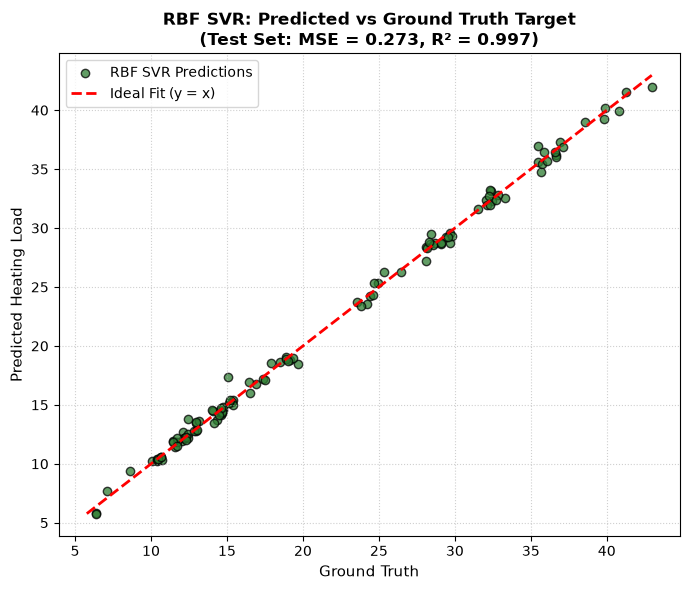

In [21]:

# Scatter plot
plt.figure(figsize=(7, 6))
plt.scatter(y_test, y_test_pred_rbf, color='#2e7d32', alpha=0.75, edgecolors='k', label='RBF SVR Predictions')

# Ideal 45-degree line (y = x)
min_val_rbf = min(y_test.min(), y_test_pred_rbf.min())
max_val_rbf = max(y_test.max(), y_test_pred_rbf.max())
plt.plot([min_val_rbf, max_val_rbf], [min_val_rbf, max_val_rbf], 'r--', lw=2, label='Ideal Fit (y = x)')

plt.title(f"RBF SVR: Predicted vs Ground Truth Target\n(Test Set: MSE = {test_mse_rbf:.3f}, R² = {test_r2_rbf:.3f})", fontsize=12, fontweight='bold')
plt.xlabel("Ground Truth", fontsize=11)
plt.ylabel("Predicted Heating Load", fontsize=11)
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend(frameon=True)
plt.tight_layout()
plt.show()